In [2]:
import requests
from bs4 import BeautifulSoup
import re
import pandas as pd
import matplotlib.pyplot as plt
from selenium import webdriver

In [3]:
url = "http://books.toscrape.com/catalogue/page-1.html"
 
response = requests.get(url)
 
# Printing the HTTP status code
print("Status Code:", response.status_code)
 
# Printing the first 500 characters
 
soup = BeautifulSoup(response.text, "lxml")
 
# Selecting all product containers
products = soup.select("article.product_pod")
 
# Creating an empty list to store sample product data
sample = []
 
# Looping through the first 3 products only
for product in products[:3]:  
    # Extracting the book title from the <a> tag inside <h3>
    name = product.h3.a["title"]
   
    # Extracting the price from the <p>
    price = product.select_one(".price_color").text
   
    # Extracting the rating from the <p>
    rating = product.p["class"][1]
   
    # Appending the extracted data as a dictionary to the sample list
    sample.append({"name": name, "price": price, "rating": rating})
 
# Displaying the sample list containing the first 3 products
sample

Status Code: 200


[{'name': 'A Light in the Attic', 'price': 'Â£51.77', 'rating': 'Three'},
 {'name': 'Tipping the Velvet', 'price': 'Â£53.74', 'rating': 'One'},
 {'name': 'Soumission', 'price': 'Â£50.10', 'rating': 'One'}]

In [5]:
# Creating an empty list to store all scraped product data
all_data = []
 
# Looping through pages 1 to 3
for page in range(1, 4):  
    # The URL dynamically for each page
    url = f"http://books.toscrape.com/catalogue/page-{page}.html"
   
    # Sending the HTTP GET request to the page
    response = requests.get(url)
   
    # Using BeautifulSoup to parse the HTML content with the lxml parser
    soup = BeautifulSoup(response.text, "lxml")
   
    # Selecting all product containers
    products = soup.select("article.product_pod")
   
    # Looping through each product found on the page
    for product in products:
        # Extracting the book title from the <a> tag inside <h3>
        name = product.h3.a["title"]
       
        # Extracting the price from the <p> tag with class "price_color"
        price = product.select_one(".price_color").text
       
        # Extracting the rating from the <p> tag’s class list
        rating = product.p["class"][1]
       
        all_data.append({"name": name, "price": price, "rating": rating})
 
len(all_data), all_data[:5]
 

(60,
 [{'name': 'A Light in the Attic', 'price': 'Â£51.77', 'rating': 'Three'},
  {'name': 'Tipping the Velvet', 'price': 'Â£53.74', 'rating': 'One'},
  {'name': 'Soumission', 'price': 'Â£50.10', 'rating': 'One'},
  {'name': 'Sharp Objects', 'price': 'Â£47.82', 'rating': 'Four'},
  {'name': 'Sapiens: A Brief History of Humankind',
   'price': 'Â£54.23',
   'rating': 'Five'}])

In [6]:
rating_map = {"One":1,"Two":2,"Three":3,"Four":4,"Five":5}
 
for item in all_data:
    item["price"] = float(re.findall(r"\d+\.\d+", item["price"])[0])
    item["rating"] = rating_map.get(item["rating"], 0)
 
df = pd.DataFrame(all_data)
df.head()

,name,price,rating
0,A Light in the Attic,51.77,3
1,Tipping the Velvet,53.74,1
2,Soumission,50.10,1
3,Sharp Objects,47.82,4
4,Sapiens: A Brief History of Humankind,54.23,5


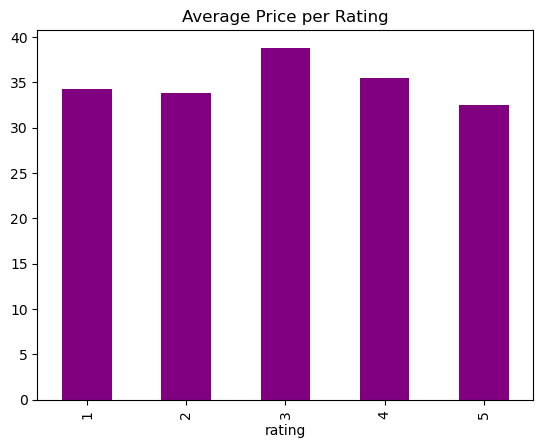

In [12]:
avg_price = df.groupby("rating")["price"].mean()
avg_price.plot(kind="bar", title="Average Price per Rating",color='purple')
plt.show()

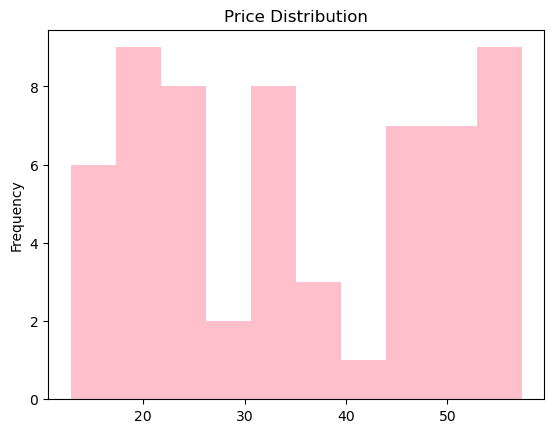

In [16]:
df["price"].plot(kind="hist", bins=10, title="Price Distribution",color='Pink')
plt.show()